In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

aapl = pd.read_csv('data/newsData/yfinance_data/Data/AAPL.csv')
print("Columns in AAPL file:")
print(aapl.columns.tolist())

Columns in AAPL file:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [8]:
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date')
aapl = aapl.reset_index(drop=True)
print(f"Date range: {aapl['Date'].min()} to {aapl['Date'].max()}")
print(f"Total rows: {len(aapl)}")
aapl.head(3)

Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
Total rows: 3774


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400


In [9]:
aapl['Daily_Return'] = aapl['Close'].pct_change() * 100
print("Daily returns calculated")
print(aapl[['Date', 'Close', 'Daily_Return']].head(10))

Daily returns calculated
        Date     Close  Daily_Return
0 2009-01-02  2.721686           NaN
1 2009-01-05  2.836553      4.220416
2 2009-01-06  2.789767     -1.649399
3 2009-01-07  2.729484     -2.160860
4 2009-01-08  2.780169      1.856959
5 2009-01-09  2.716589     -2.286921
6 2009-01-12  2.659007     -2.119649
7 2009-01-13  2.630514     -1.071572
8 2009-01-14  2.559135     -2.713489
9 2009-01-15  2.500652     -2.285260


In [10]:
aapl['SMA_20'] = aapl['Close'].rolling(window=20).mean()
aapl['SMA_50'] = aapl['Close'].rolling(window=50).mean()
aapl['SMA_200'] = aapl['Close'].rolling(window=200).mean()
print("SMAs calculated")
print(aapl[['Date', 'Close', 'SMA_20', 'SMA_50']].tail(10))

SMAs calculated
           Date       Close      SMA_20      SMA_50
3764 2023-12-15  195.721619  190.723320  181.953393
3765 2023-12-18  194.057343  191.030421  182.322577
3766 2023-12-19  195.097504  191.302353  182.682884
3767 2023-12-20  193.007248  191.509893  183.013258
3768 2023-12-21  192.858643  191.676816  183.312761
3769 2023-12-22  191.788757  191.856618  183.572859
3770 2023-12-26  191.243912  192.018094  183.858864
3771 2023-12-27  191.342972  192.154308  184.149424
3772 2023-12-28  191.768951  192.362839  184.479567
3773 2023-12-29  190.728775  192.490633  184.814828


In [11]:
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

aapl['RSI'] = calculate_rsi(aapl['Close'])
print(f"RSI range: {aapl['RSI'].min():.2f} to {aapl['RSI'].max():.2f}")
print(f"Latest RSI: {aapl['RSI'].iloc[-1]:.2f}")
aapl[['Date', 'Close', 'RSI']].tail(10)

RSI range: 3.18 to 97.49
Latest RSI: 40.19


,Date,Close,RSI
3764,2023-12-15,195.721619,67.844044
3765,2023-12-18,194.057343,62.002656
3766,2023-12-19,195.097504,66.535539
3767,2023-12-20,193.007248,59.991800
3768,2023-12-21,192.858643,57.388276
3769,2023-12-22,191.788757,59.246127
3770,2023-12-26,191.243912,49.031899
3771,2023-12-27,191.342972,52.291510
3772,2023-12-28,191.768951,47.920425
3773,2023-12-29,190.728775,40.185234


In [12]:
ema_12 = aapl['Close'].ewm(span=12, adjust=False).mean()
ema_26 = aapl['Close'].ewm(span=26, adjust=False).mean()
aapl['MACD'] = ema_12 - ema_26
aapl['Signal'] = aapl['MACD'].ewm(span=9, adjust=False).mean()
aapl['MACD_Histogram'] = aapl['MACD'] - aapl['Signal']
print("MACD calculated")
print(aapl[['Date', 'Close', 'MACD', 'Signal', 'MACD_Histogram']].tail(10))

MACD calculated
           Date       Close      MACD    Signal  MACD_Histogram
3764 2023-12-15  195.721619  3.745908  3.574956        0.170952
3765 2023-12-18  194.057343  3.582111  3.576387        0.005724
3766 2023-12-19  195.097504  3.495934  3.560297       -0.064363
3767 2023-12-20  193.007248  3.221832  3.492604       -0.270771
3768 2023-12-21  192.858643  2.958510  3.385785       -0.427275
3769 2023-12-22  191.788757  2.633141  3.235256       -0.602115
3770 2023-12-26  191.243912  2.304751  3.049155       -0.744404
3771 2023-12-27  191.342972  2.029104  2.845145       -0.816041
3772 2023-12-28  191.768951  1.823998  2.640915       -0.816918
3773 2023-12-29  190.728775  1.559539  2.424640       -0.865101


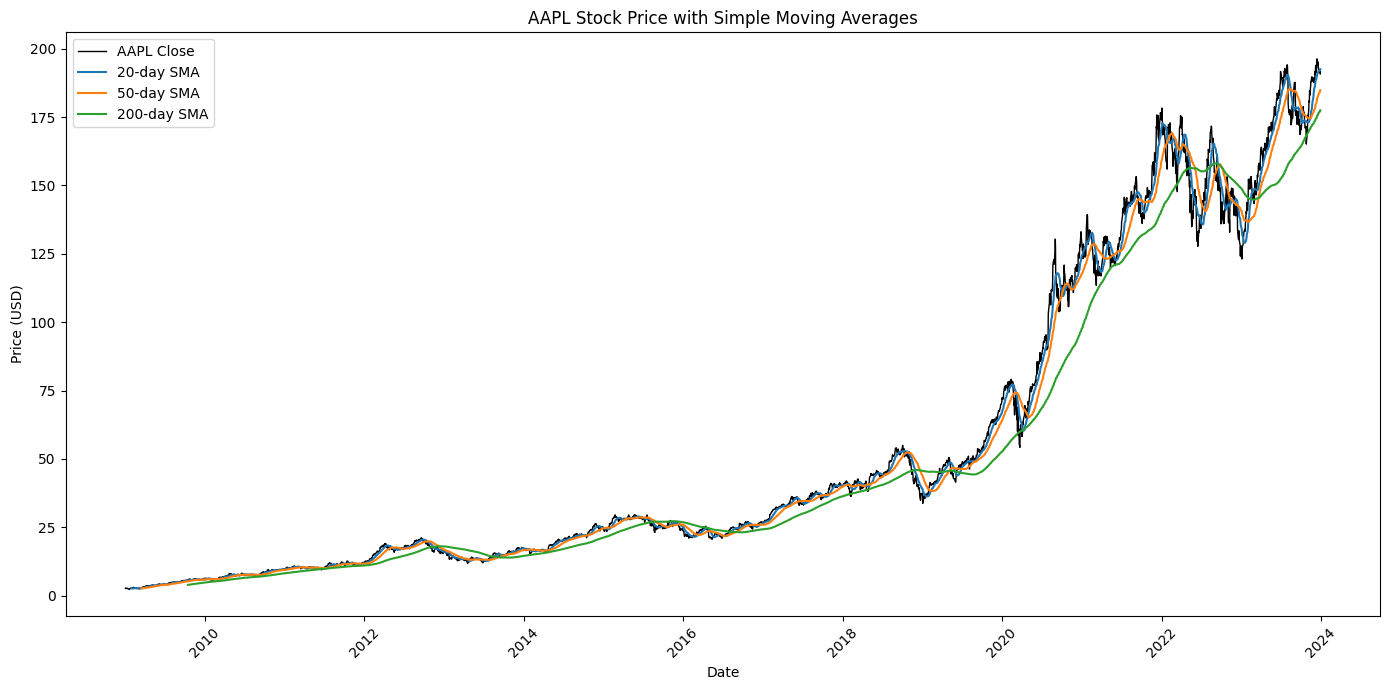

Chart 1 displayed


In [13]:
plt.figure(figsize=(14,7))
plt.plot(aapl['Date'], aapl['Close'], label='AAPL Close', linewidth=1, color='black')
plt.plot(aapl['Date'], aapl['SMA_20'], label='20-day SMA', linewidth=1.5)
plt.plot(aapl['Date'], aapl['SMA_50'], label='50-day SMA', linewidth=1.5)
plt.plot(aapl['Date'], aapl['SMA_200'], label='200-day SMA', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('AAPL Stock Price with Simple Moving Averages')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Chart 1 displayed")

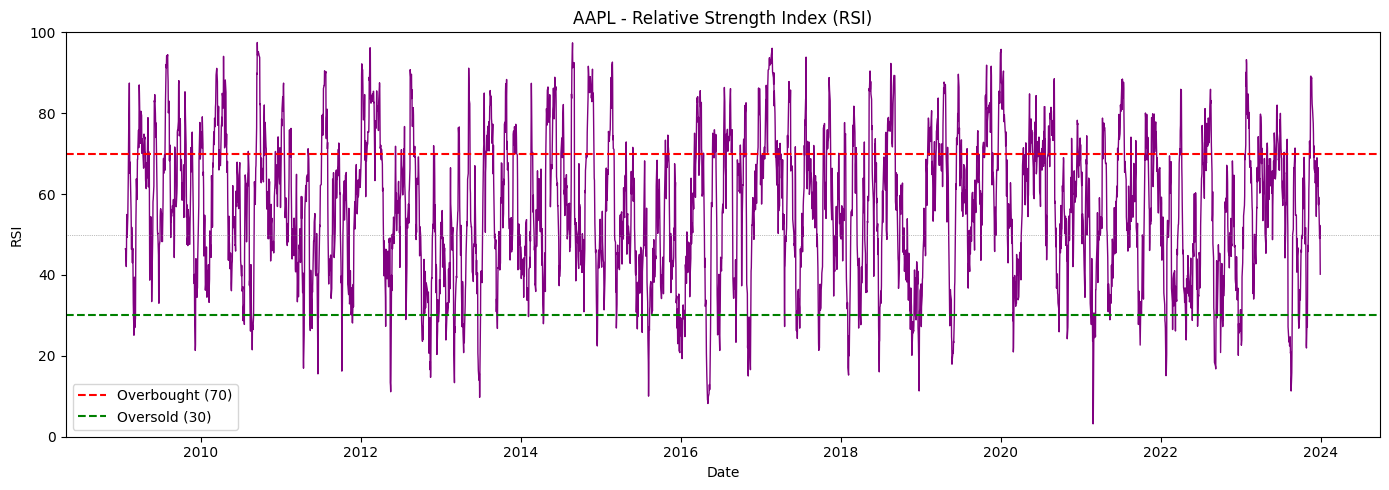

Chart 2 displayed - RSI


In [14]:
plt.figure(figsize=(14,5))
plt.plot(aapl['Date'], aapl['RSI'], color='purple', linewidth=1)
plt.axhline(y=70, color='r', linestyle='--', label='Overbought (70)', linewidth=1.5)
plt.axhline(y=30, color='g', linestyle='--', label='Oversold (30)', linewidth=1.5)
plt.axhline(y=50, color='gray', linestyle=':', linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('RSI')
plt.title('AAPL - Relative Strength Index (RSI)')
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
print("Chart 2 displayed - RSI")

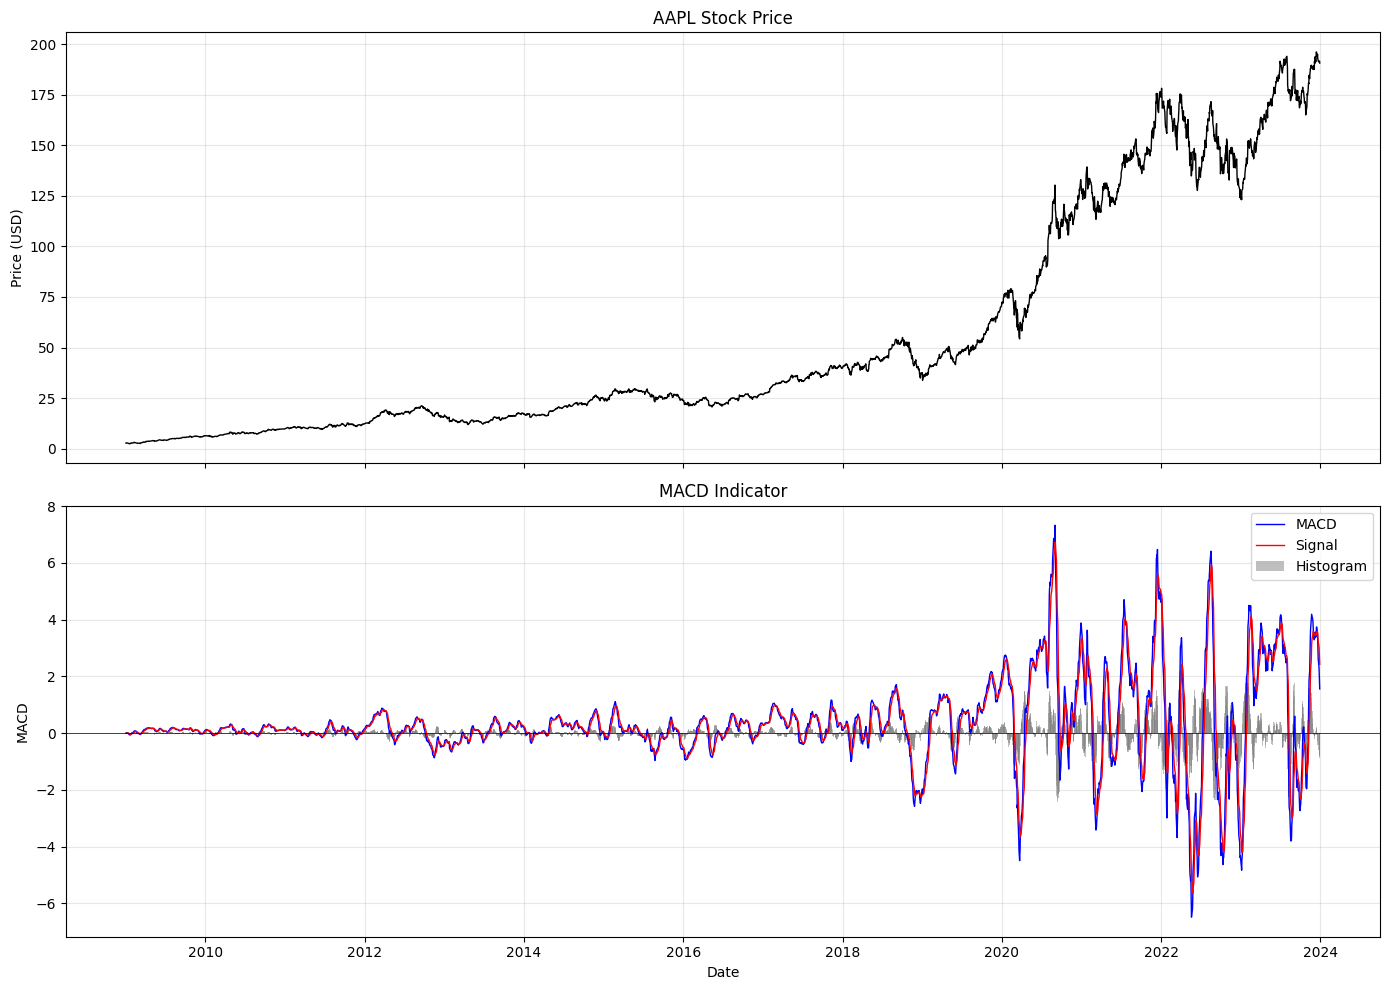

Chart 3 displayed - MACD


In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price chart (top)
ax1.plot(aapl['Date'], aapl['Close'], color='black', linewidth=1)
ax1.set_ylabel('Price (USD)')
ax1.set_title('AAPL Stock Price')
ax1.grid(True, alpha=0.3)

# MACD chart (bottom)
ax2.plot(aapl['Date'], aapl['MACD'], label='MACD', color='blue', linewidth=1)
ax2.plot(aapl['Date'], aapl['Signal'], label='Signal', color='red', linewidth=1)
ax2.bar(aapl['Date'], aapl['MACD_Histogram'], label='Histogram', color='gray', alpha=0.5, width=5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('MACD')
ax2.set_title('MACD Indicator')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Chart 3 displayed - MACD")


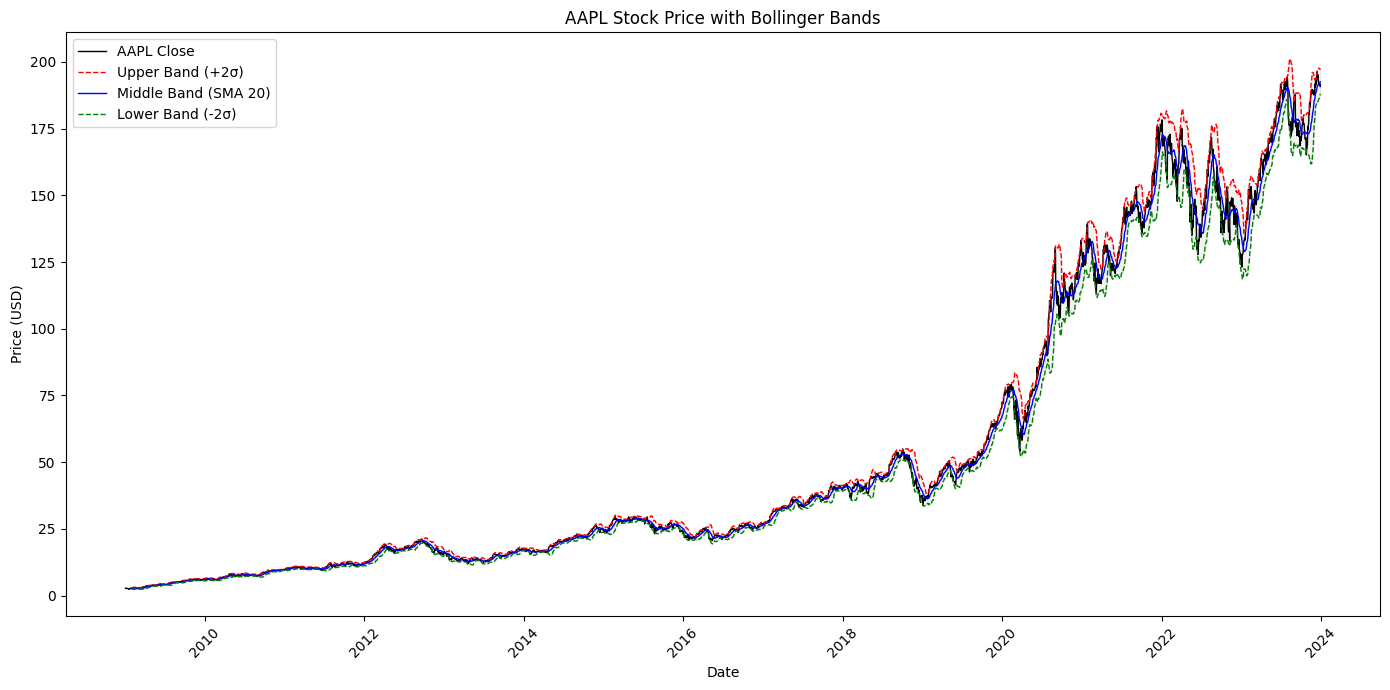

Chart 4 displayed - Bollinger Bands


In [16]:
# Calculate Bollinger Bands
aapl['BB_Middle'] = aapl['SMA_20']
aapl['BB_Upper'] = aapl['BB_Middle'] + (aapl['Close'].rolling(window=20).std() * 2)
aapl['BB_Lower'] = aapl['BB_Middle'] - (aapl['Close'].rolling(window=20).std() * 2)

# Plot Bollinger Bands
plt.figure(figsize=(14,7))
plt.plot(aapl['Date'], aapl['Close'], label='AAPL Close', color='black', linewidth=1)
plt.plot(aapl['Date'], aapl['BB_Upper'], label='Upper Band (+2σ)', color='red', linestyle='--', linewidth=1)
plt.plot(aapl['Date'], aapl['BB_Middle'], label='Middle Band (SMA 20)', color='blue', linewidth=1)
plt.plot(aapl['Date'], aapl['BB_Lower'], label='Lower Band (-2σ)', color='green', linestyle='--', linewidth=1)
plt.fill_between(aapl['Date'], aapl['BB_Upper'], aapl['BB_Lower'], alpha=0.1, color='gray')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('AAPL Stock Price with Bollinger Bands')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Chart 4 displayed - Bollinger Bands")

In [17]:
print("="*60)
print("TECHNICAL INDICATORS SUMMARY - AAPL")
print("="*60)
print(f"Date range: {aapl['Date'].min()} to {aapl['Date'].max()}")
print(f"Latest date: {aapl['Date'].iloc[-1]}")
print(f"Latest closing price: ${aapl['Close'].iloc[-1]:.2f}")
print(f"\n--- MOVING AVERAGES ---")
print(f"20-day SMA: ${aapl['SMA_20'].iloc[-1]:.2f}")
print(f"50-day SMA: ${aapl['SMA_50'].iloc[-1]:.2f}")
print(f"200-day SMA: ${aapl['SMA_200'].iloc[-1]:.2f}")
print(f"\n--- RSI (Relative Strength Index) ---")
print(f"Current RSI: {aapl['RSI'].iloc[-1]:.2f}")
if aapl['RSI'].iloc[-1] > 70:
    print("→ OVERBOUGHT condition (RSI > 70) - Possible price drop")
elif aapl['RSI'].iloc[-1] < 30:
    print("→ OVERSOLD condition (RSI < 30) - Possible price increase")
else:
    print("→ Neutral RSI (30-70) - Normal trading range")
print(f"\n--- MACD ---")
print(f"Current MACD: {aapl['MACD'].iloc[-1]:.4f}")
print(f"Current Signal: {aapl['Signal'].iloc[-1]:.4f}")
if aapl['MACD'].iloc[-1] > aapl['Signal'].iloc[-1]:
    print("→ BULLISH signal (MACD above Signal line)")
else:
    print("→ BEARISH signal (MACD below Signal line)")
print(f"\n--- BOLLINGER BANDS ---")
print(f"Upper Band: ${aapl['BB_Upper'].iloc[-1]:.2f}")
print(f"Middle Band: ${aapl['BB_Middle'].iloc[-1]:.2f}")
print(f"Lower Band: ${aapl['BB_Lower'].iloc[-1]:.2f}")
if aapl['Close'].iloc[-1] > aapl['BB_Upper'].iloc[-1]:
    print("→ Price ABOVE upper band - Overextended")
elif aapl['Close'].iloc[-1] < aapl['BB_Lower'].iloc[-1]:
    print("→ Price BELOW lower band - Oversold")
else:
    print("→ Price within bands - Normal range")
print("="*60)

TECHNICAL INDICATORS SUMMARY - AAPL
Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
Latest date: 2023-12-29 00:00:00
Latest closing price: $190.73

--- MOVING AVERAGES ---
20-day SMA: $192.49
50-day SMA: $184.81
200-day SMA: $177.45

--- RSI (Relative Strength Index) ---
Current RSI: 40.19
→ Neutral RSI (30-70) - Normal trading range

--- MACD ---
Current MACD: 1.5595
Current Signal: 2.4246
→ BEARISH signal (MACD below Signal line)

--- BOLLINGER BANDS ---
Upper Band: $196.96
Middle Band: $192.49
Lower Band: $188.02
→ Price within bands - Normal range


In [18]:
print("="*60)
print("TASK 2 COMPLETED SUCCESSFULLY!")
print("="*60)
print("Technical Indicators Implemented:")
print("✅ 1. Daily Returns")
print("✅ 2. Simple Moving Averages (20, 50, 200-day)")
print("✅ 3. RSI (Relative Strength Index)")
print("✅ 4. MACD (Moving Average Convergence Divergence)")
print("✅ 5. Bollinger Bands")
print("="*60)

TASK 2 COMPLETED SUCCESSFULLY!
Technical Indicators Implemented:
✅ 1. Daily Returns
✅ 2. Simple Moving Averages (20, 50, 200-day)
✅ 3. RSI (Relative Strength Index)
✅ 4. MACD (Moving Average Convergence Divergence)
✅ 5. Bollinger Bands
